In [1]:
import sys

sys.path.append('../src/')
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps
from libselection.utils import *
from libselection import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

# Data Generation

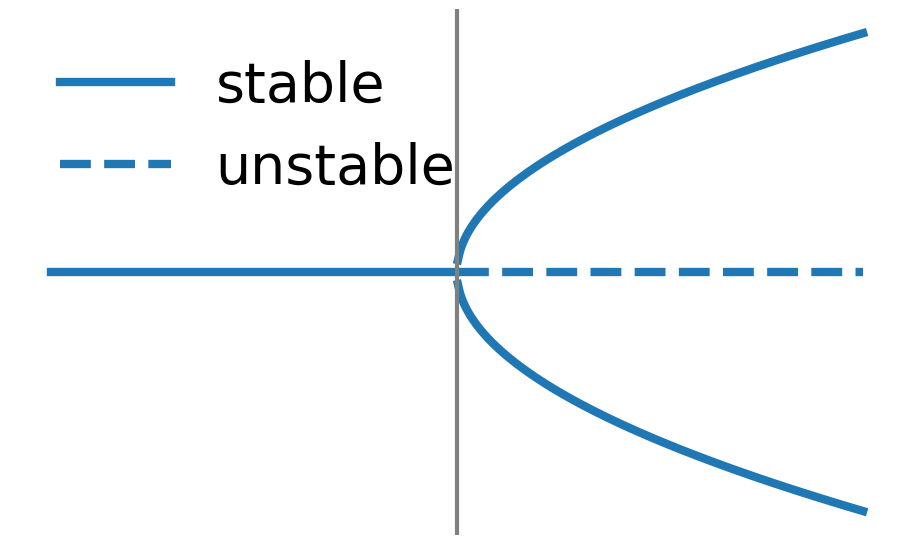

In [2]:
mu = np.linspace(-1, 1, 400)

# Equilibrium branches
x0 = np.zeros_like(mu)             # x = 0
xplus  = np.sqrt(np.maximum(mu, 0))
xminus = -np.sqrt(np.maximum(mu, 0))

fig, ax = plt.subplots(figsize=(10,6))
lw=6
clr = '#1f77b4'
# Unstable branch (x=0 for mu>0)
ax.plot(mu[mu<0], x0[mu<0], '-',  label='stable', lw=lw, c=clr)
ax.plot(mu[mu>0], x0[mu>0], '--', label='unstable', lw=lw, c=clr)

# Stable side branches (mu>0)
ax.plot(mu[mu>0],  xplus[mu>0],  '-', lw=lw, c=clr)
ax.plot(mu[mu>0],  xminus[mu>0], '-', lw=lw, c=clr)

ax.axvline(0, color='gray', linewidth=3)
ax.set_xlabel(r'$\mu$')
ax.set_ylabel(r'$x^*$')
# ax.set_title('Pitchfork bifurcation: equilibria vs parameter')
ax.legend(frameon=False, loc='upper left', fontsize=40)

plt.tight_layout()

ax.set_axis_off()
plt.savefig('Figs/pitchfork_attractor.png', dpi=1200)

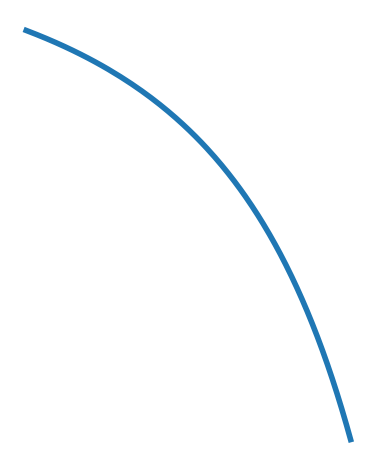

In [3]:
# Pitchfork system parameters
mu = 5e-1

def pitch_fork(t, state, mu):
    x,y = state
    dxdt = mu*x - x**3
    dydt = -y
    return [dxdt, dydt]


# Time range for simulation
dt = 0.01
t = np.arange(0, 10 + 2*dt, dt)
# Initial condition
initial_state = [-1.5,1]
integrator_keywords = {}
integrator_keywords["rtol"] = 1e-12
integrator_keywords["method"] = "RK45"
integrator_keywords["atol"] = 1e-12
# Solve the Pitch Fork system
pitch_fork_data = solve_ivp(pitch_fork, (t[0], t[-1]), initial_state, t_eval=t, args=(mu,), **integrator_keywords).y.T

# Plot the Pitch Fork attractor
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(pitch_fork_data[:,0], pitch_fork_data[:,1], lw=4)

ax.set_axis_off()
ax.set_aspect('equal')
plt.tight_layout()
# plt.savefig('Figs/pitchfork_attractor.png', dpi=1200)
plt.show()

x_train = pitch_fork_data
t_train = t
var_names = ['x','y']

library_gen = ps.PolynomialLibrary(degree=3) #+ ps.FourierLibrary(n_frequencies=2)
D = np.array(library_gen.fit_transform(x_train))
_, No_D = D.shape
name_tag = np.array(library_gen.get_feature_names(var_names))
x_dot = non_uniform_diff(x_train, t_train)

# Compute Scores

## Standard formulation

(9, 10)


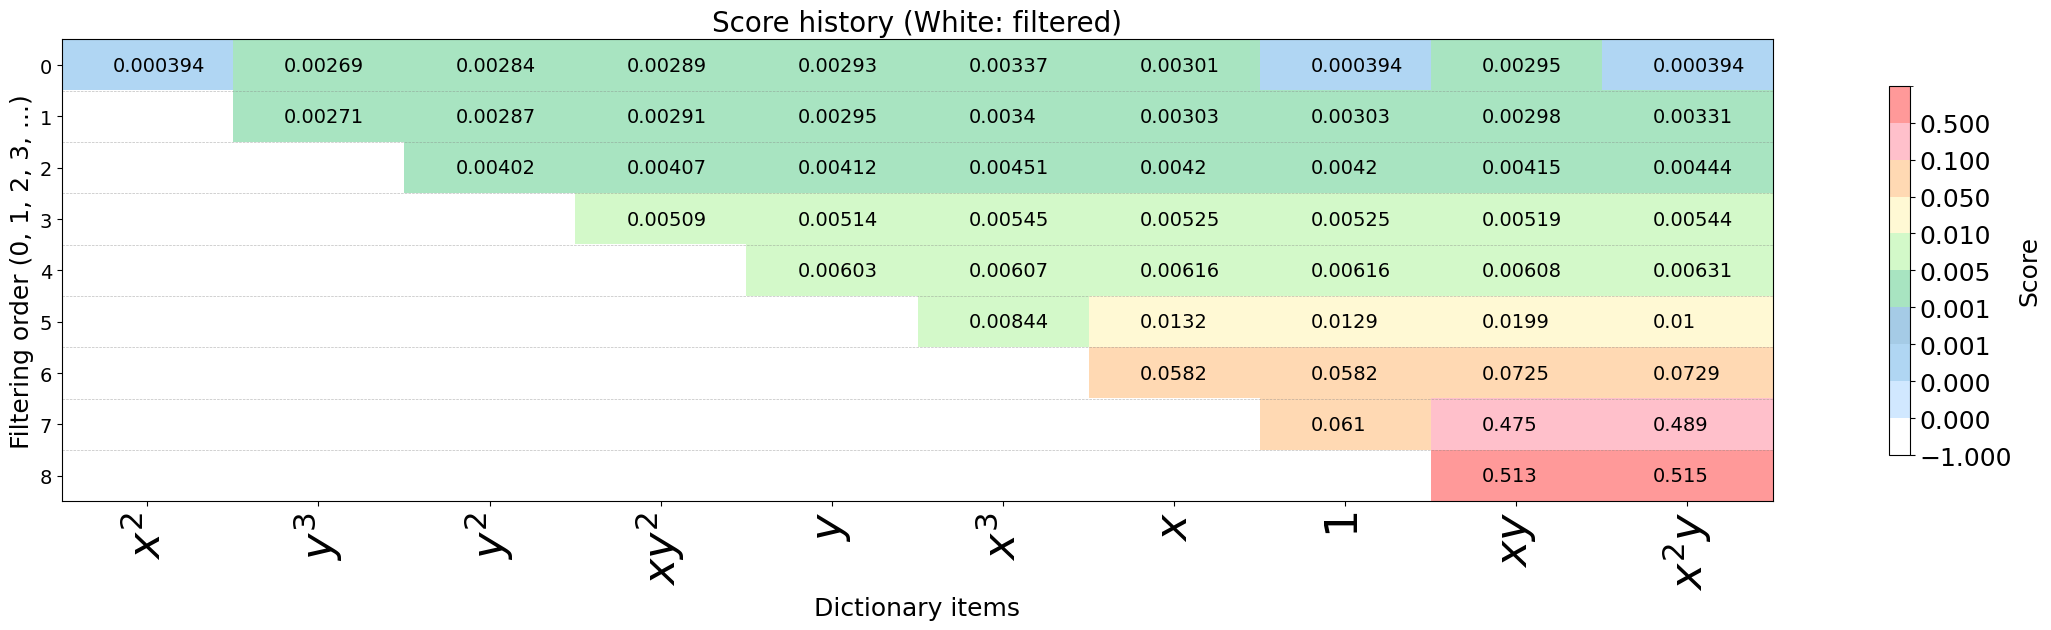

In [4]:
# filtering
plt.rcParams.update({'font.size': 14})
best_comb, removed_order, history_values = iter_scores(D, x_dot, n_terms=1, stepwise=True, backwards=True, stepsize=1)

# plot_filtering_history_sorted(removed_order, history_values, name_tag, save_path='Figs/filtering_history_pitchfork.pdf', diff_score=False, backwards = True,print_inside=False,save_eps=True)
plot_filtering_history_sorted(removed_order, history_values, name_tag, save_path=None, diff_score=False, backwards = True,print_inside=True,save_eps=True)

## Weak form

125.25 1.2525
(9, 10)


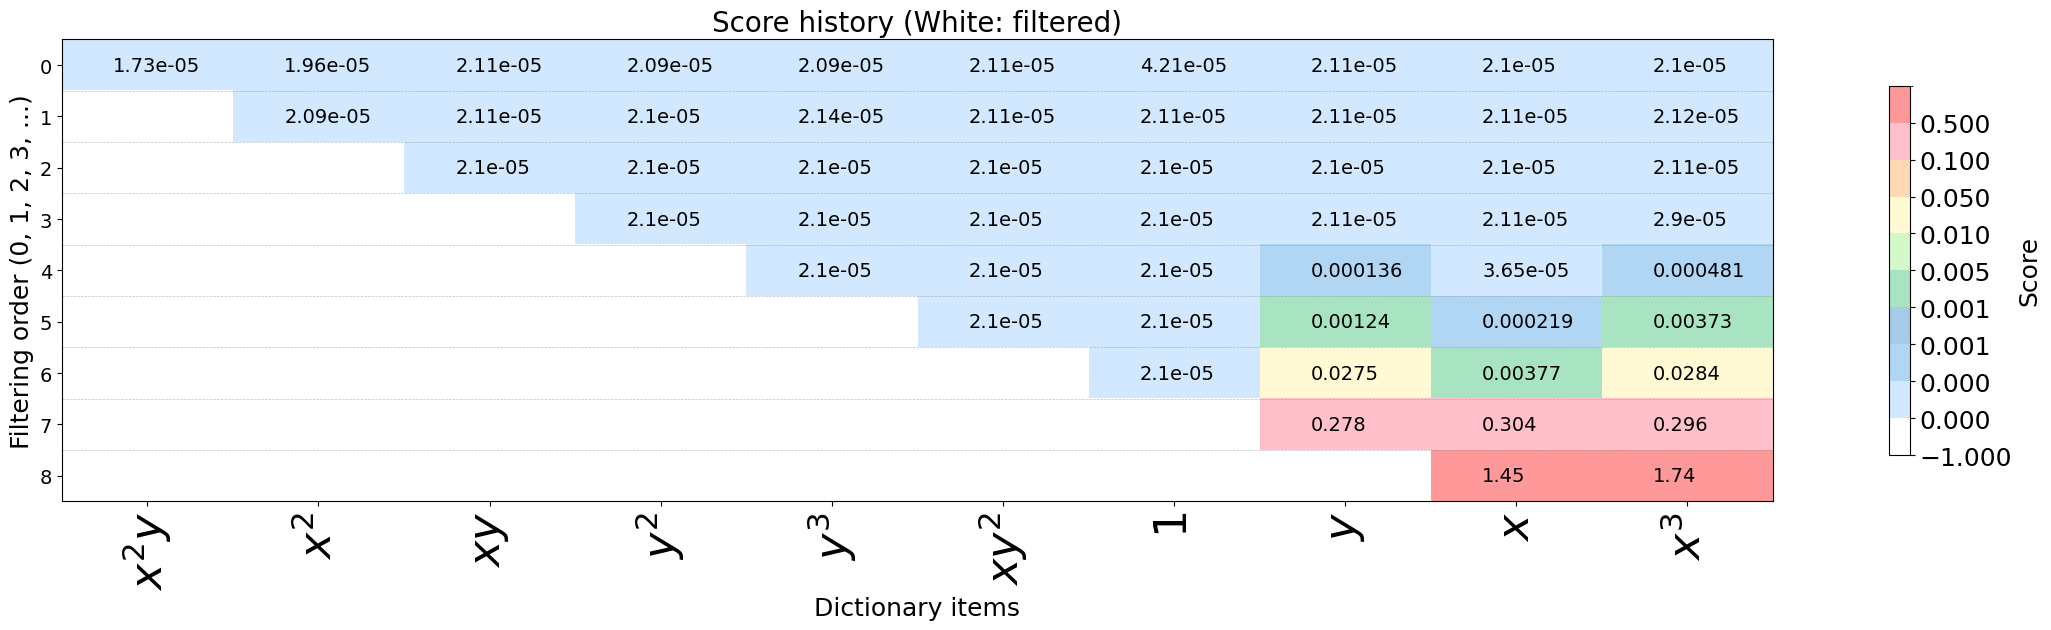

In [5]:
# Weak form support size computation
x_var =x_train
# Compute the Fourier transform of Y
fft_values = np.fft.fft(x_var - x_var.mean(axis=0), axis=0)
# Compute the magnitude of the Fourier modes
magnitudes = np.abs(fft_values)
# Find the maximum magnitude for each variable

max_magnitude_indices = np.argmax(magnitudes) + 1

# Compute L for each variable
M = x_var.shape[0]  # Number of samples
sps = 0.5 * (M / max_magnitude_indices) 
L = sps * dt
print(sps, L)
# Exhaustive filtering
V, dV = generate_overlapping_test_function_matrices(t_train, 2*No_D, l=1.2525, p=17)
G = V@D
b = -dV@x_train

best_comb, removed_order, history_values = iter_scores( G, b, n_terms=1, stepwise=True, backwards=True, stepsize=1)
plot_filtering_history_sorted(removed_order, history_values, name_tag, save_path=None, save_eps=True, diff_score=False, backwards = True,print_inside=True)

In [6]:
# SINDy identification
C = SINDy(b,G,eps = 0.1)
print('SINDy identification before filtering:')
print_model(C, name_tag)
print()
# SINDy identification after filtering
G_filtered = G[:, removed_order[-3:]]
C_filtered = SINDy(b,G_filtered,eps = 0.1)
print('SINDy identification after filtering:')
print_model(C_filtered, name_tag[removed_order[-3:]])

SINDy identification before filtering:
x0' = 1.766 1 + 0.500 x + -3.531 x^2 + -1.000 x^3 + 2.747 x^2 y 
x1' = 4.087 1 + -1.000 y + -8.173 x^2 + 6.357 x^2 y 

SINDy identification after filtering:
x0' = 0.500 x + -1.000 x^3 
x1' = -1.000 y 


In [7]:
n_vars = len(var_names)
x_terms = [1,6]  # Manually set based on previous jumps detected
y_terms = [2]  # Manually set based on previous jumps detected
correct_terms = [x_terms, y_terms]

history_value_removed = np.zeros((n_vars,No_D))
filtering_order = np.zeros((n_vars,No_D), dtype=int)

history_value_pareto = np.zeros((n_vars,No_D))
filtering_order_pareto = np.zeros((n_vars,No_D), dtype=int)

history_value_cv = np.zeros((n_vars,No_D))
filtering_order_cv = np.zeros((n_vars,No_D), dtype=int)


for var in range(n_vars):
    _, history_index, history_value = iter_scores( G, b[:,var:var+1], n_terms=1, stepwise=True, backwards=True, stepsize=1)
    history_value_pareto[var,:], filtering_order_pareto[var,:] = get_pareto_scores(G, b[:,var:var+1])
    history_value_cv[var,:], filtering_order_cv[var,:] = get_cv_scores(G, b[:,var:var+1])

    # Determine the filtering order
    filtering_order[var,:] = history_index
    for i in range(No_D - 1):
        history_value_removed[var,i] = history_value[i, filtering_order[var,i]]
    history_value_removed[var,-1] = history_value[-1, filtering_order[var, -1]]

[7 8]
Jump in $x$ at index 9: x^3
Jump in $x$ at index 8: x
[8]
Jump in $y$ at index 9: y


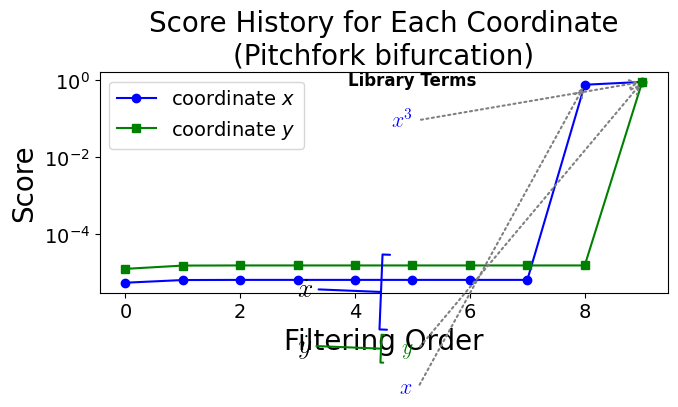

In [8]:

plt.figure(figsize=(7, 5))
coords = ['$x$', '$y$']
markers = ['o', 's', 'v']
colors = ['b', 'g', 'm']
plt.plot(history_value_removed[0], color=colors[0], marker=markers[0], label=f'coordinate {coords[0]}')
plt.plot(history_value_removed[1], color=colors[1], marker=markers[1], label=f'coordinate {coords[1]}')
plt.yscale('log')
plt.xlabel('Filtering Order', fontsize=20)
plt.ylabel('Score', fontsize=20)
plt.title('Score History for Each Coordinate\n(Pitchfork bifurcation)', fontsize=20)
plt.legend(fontsize=14)
# plt.xticks(np.arange(len(name_tag)), name_tag, rotation=90, fontsize=10)

# Detect and print jumps
height = 0.09
loc = 5
plt.text(
    loc, 1, 
    f"Library Terms", 
    ha='center', va='center', fontsize=12, color='k', fontweight='bold'
)
h=0
for idx in range(2):
    scores = history_value_removed[idx]
    jumps = np.where(((scores[1:]/scores[:-1]) > 1)*(scores[1:]> 0.01))[0] # Heuristic: jump > 10x median diff
    print(jumps)
    for j in range(No_D-2, jumps[0]-1,-1):
        h+=1
        print(f"Jump in {coords[idx]} at index {j+1}: {name_tag[filtering_order[idx, j+1]]}")
        # Set annotation color to match the line color
        line = plt.gca().lines[idx]
        color = line.get_color()
        # Draw an arrow to the jump point
        plt.annotate(
            '', 
            xy=(j+1, scores[j+1]), 
            xytext=(loc+0.1, height),  # Arrow starts from top left
            arrowprops=dict(arrowstyle="->", color='gray', lw=1.5,linestyle='dotted') ,
            annotation_clip=False
        )
        # Write the name at the top left, stacking vertically
        with mpl.rc_context({'text.usetex': True, 'font.family': 'serif'}):
            plt.text(
                loc, height, 
                f"${name_tag[filtering_order[idx, j+1]]}$", 
                ha='right', va='center', fontsize=16, color=color, fontweight='bold'
            )

        height = 10**(-j)  # Increment height for next annotation
    with mpl.rc_context({'text.usetex': True, 'font.family': 'serif'}):
        if idx == 0:
            plt.annotate(
                '$\dot{x}$', 
                xy=(loc-0.5, height*3e1), 
                xytext=(loc-2,  height*2.4e1),  # Arrow starts from top left
                arrowprops=dict(arrowstyle="-[", color=color, lw=1.5, mutation_scale=27) ,
                annotation_clip=False,
                fontsize=20
            )
        elif idx == 1:
            plt.annotate(
                '$\dot{y}$', 
                xy=(loc-0.5, height*1e1), 
                xytext=(loc-2,  height*8),  # Arrow starts from top left
                arrowprops=dict(arrowstyle="-[", color=color, lw=1.5,mutation_scale=10) ,
                annotation_clip=False,
                fontsize=20
            )

plt.tight_layout()
plt.savefig('Figs/score_history_each_coordinate_pitchfork.pdf', format='pdf')
# plt.show()

In [9]:
# Detect and print jumps

def detect_jumps(history_value_removed,filtering_order,ax, n_var=2, height = 0.09, loc = 5, fs=30, vmin=1e-5, vmax=1):
    step =-np.log10((vmin))/15
    ax.text(
        loc-1, .95, 
        f"Library Terms", 
        ha='center', va='center', fontsize=fs, color='k', fontweight='bold'
    )
    for idx in range(n_var):
        scores = history_value_removed[idx]
        jumps = np.where(((scores[1:]/scores[:-1]) > 1)*(scores[1:]> 0.01))[0] # Heuristic: jump > 10x median diff
        print(jumps)
        max_h = height
        for j in range(No_D-2, jumps[0]-1,-1):
            print(f"Jump in {coords[idx]} at index {j+1}: {name_tag[filtering_order[idx, j+1]]}")
            # Set annotation color to match the line color
            line = ax.lines[idx]
            color = line.get_color()
            # Draw an arrow to the jump point
            ax.annotate(
                '', 
                xy=(j+1, scores[j+1]), 
                xytext=(loc+0.1, height),  # Arrow starts from top left
                arrowprops=dict(arrowstyle="->", color='gray', lw=1.5,linestyle='dotted') ,
                annotation_clip=False
            )
            # Write the name at the top left, stacking vertically
            with mpl.rc_context({'text.usetex': True, 'font.family': 'serif'}):
                ax.text(
                    loc, height, 
                    f"${name_tag[filtering_order[idx, j+1]]}$", 
                    ha='right', va='center', fontsize=fs, color=color, fontweight='bold'
                )

            height = 10**(-j*step)  # Increment height for next annotation
        min_h = height/step
        with mpl.rc_context({'text.usetex': True, 'font.family': 'serif'}):
            if idx == 0:
                ax.annotate(
                    '$\dot{x}$', 
                    xy=(loc-0.5, (max_h + min_h)/2), 
                    xytext=(loc-2,  (max_h + min_h)/2),  # Arrow starts from top left
                    arrowprops=dict(arrowstyle="-[", color=color, lw=1.5, mutation_scale=27) ,
                    annotation_clip=False,
                    fontsize=fs
                )
            elif idx == 1:
                ax.annotate(
                    '$\dot{y}$', 
                    xy=(loc-0.5, height*1e1), 
                    xytext=(loc-2,  height*8),  # Arrow starts from top left
                    arrowprops=dict(arrowstyle="-[", color=color, lw=1.5,mutation_scale=10) ,
                    annotation_clip=False,
                    fontsize=fs
                )


C:\Users\fabio\AppData\Local\Temp\ipykernel_42396\1188371147.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


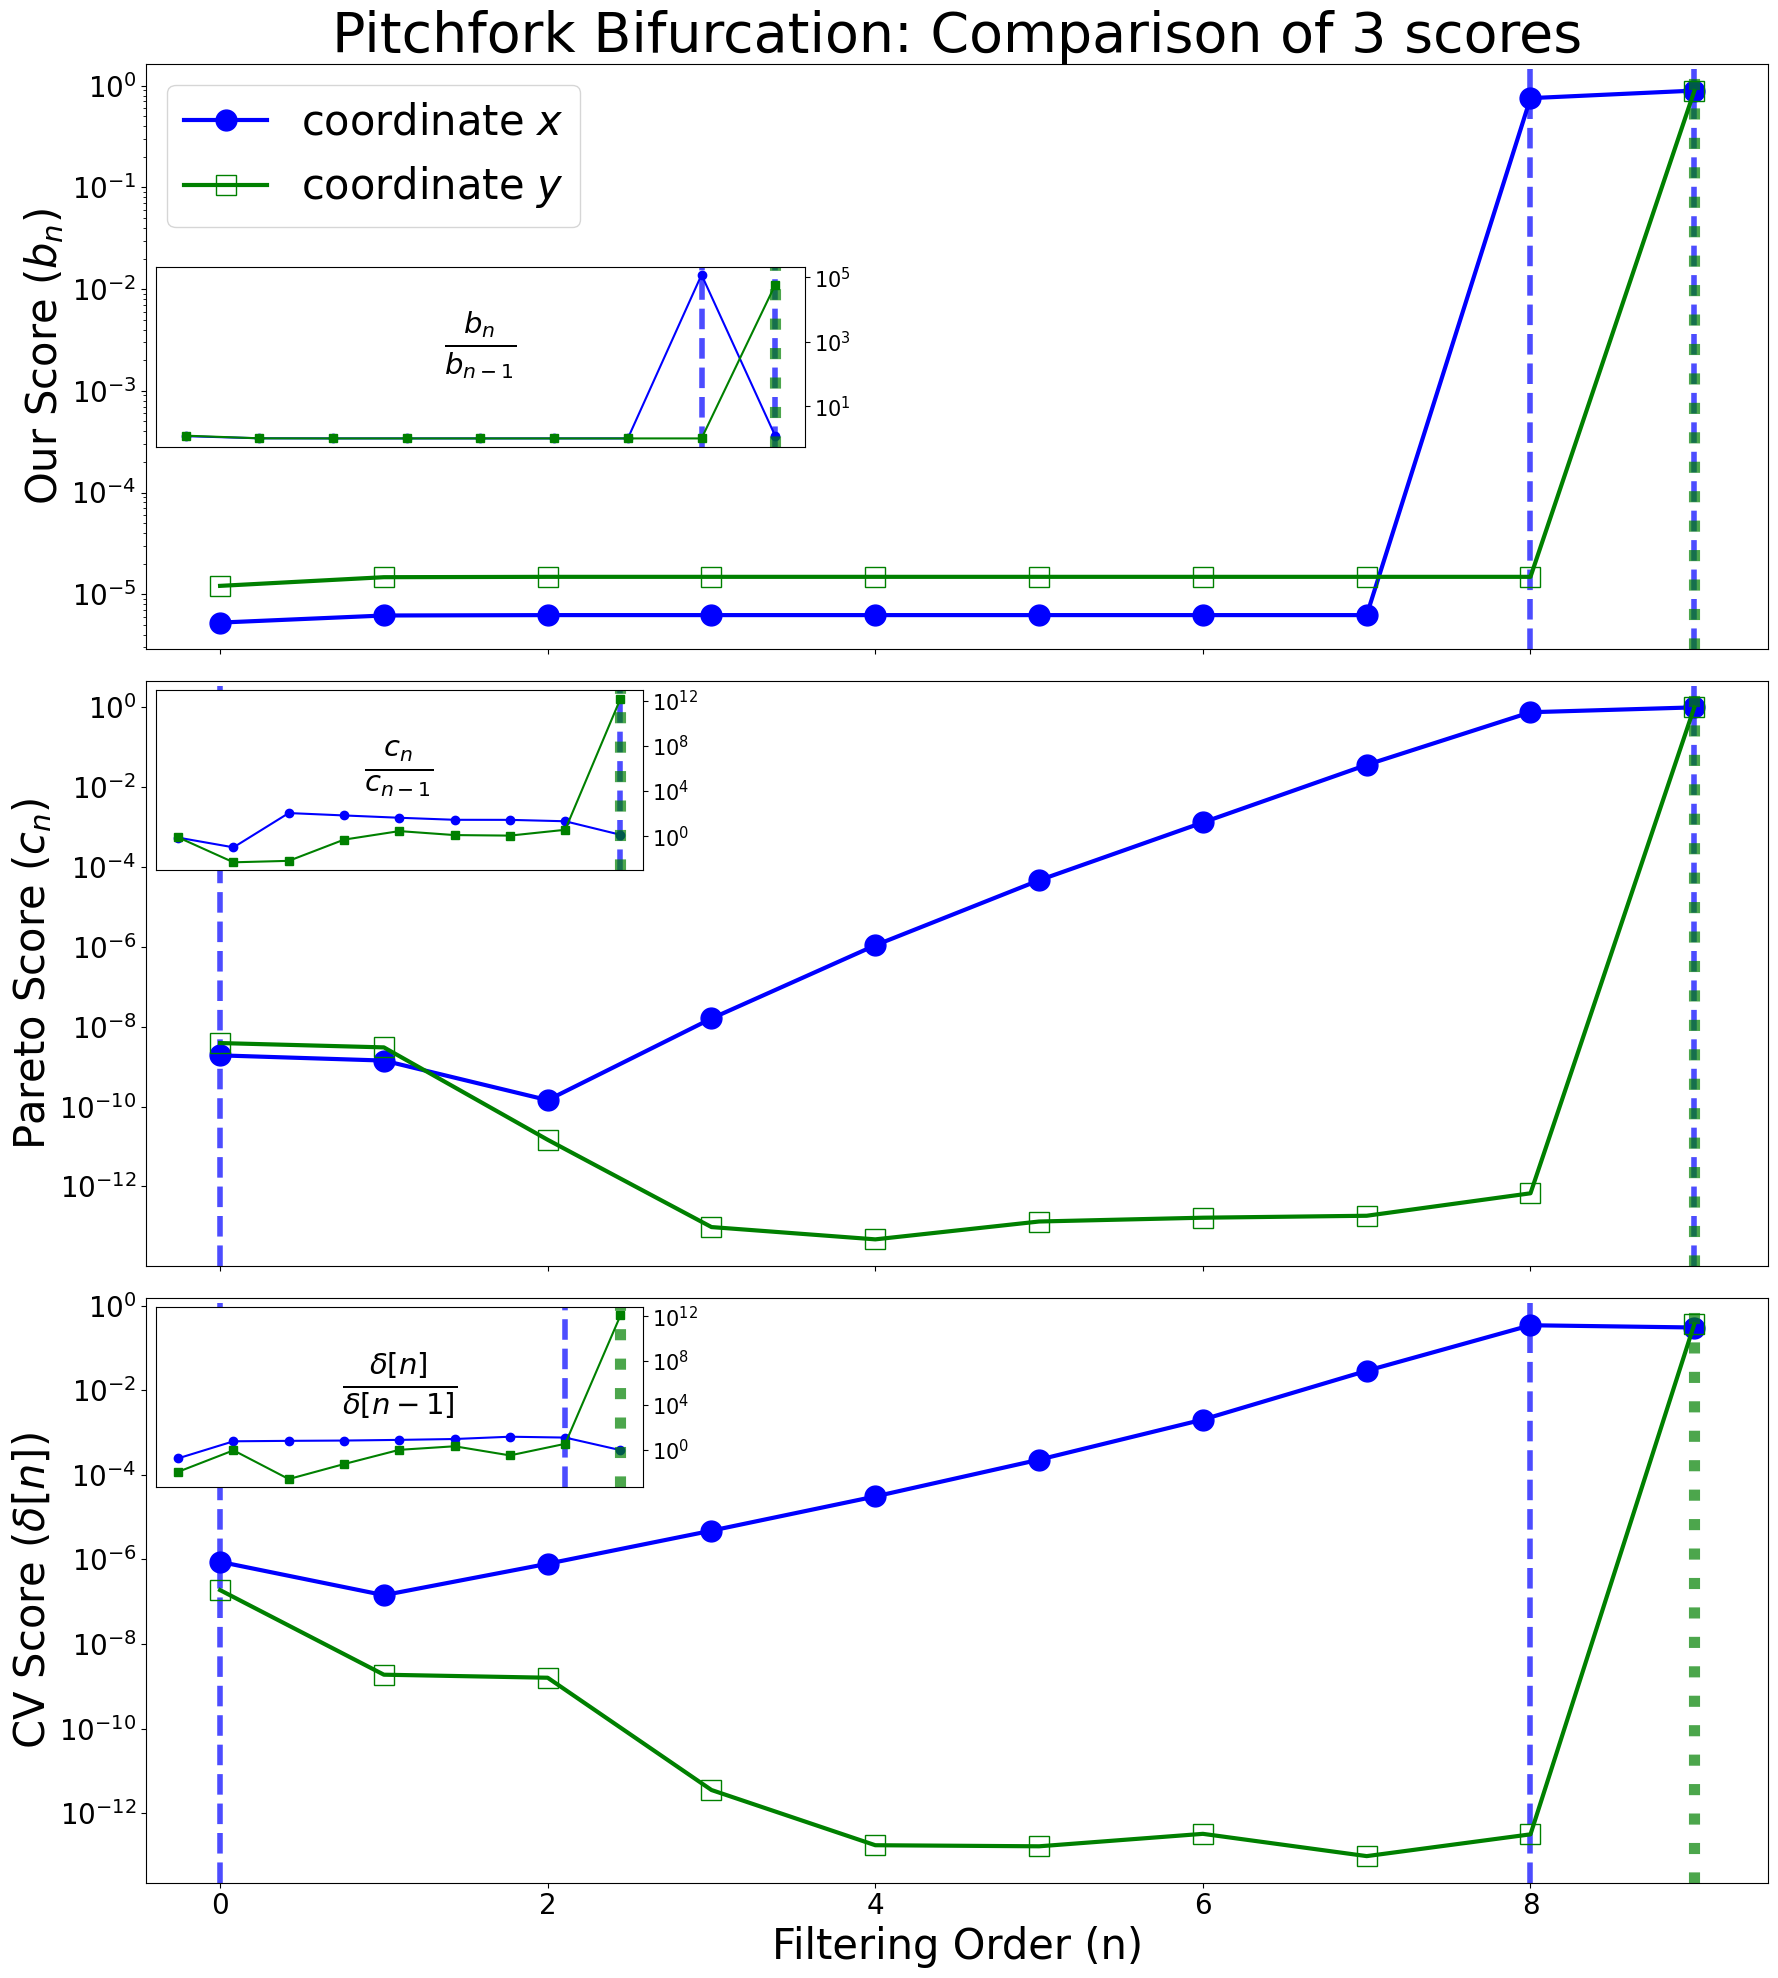

In [ ]:
#create figure
line_style = ['dashed', 'dotted']
sizes = [4,8]
fs = 30
fig, ax = plt.subplots(3,1,figsize=(18, 20), sharex=True)

ax[0].set_title('Pitchfork Bifurcation: Comparison of 3 scores', fontsize=40)
n_terms = [2,1]  # Manually set based on previous jumps detected
n_terms = [No_D - n for n in n_terms]

filt_order = []
filt_order.append(filtering_order)
filt_order.append(filtering_order_pareto)
filt_order.append(filtering_order_cv)

rel_scores = []
rel_scores.append(history_value_removed[:,1:] / history_value_removed[:,:-1])
rel_scores.append(history_value_pareto[:,1:] / history_value_pareto[:,:-1])
rel_scores.append(history_value_cv[:,1:] / history_value_cv[:,:-1])

inset_axs = []
inset_axs.append(inset_axes(ax[0],
                    width="40%", # width = 40% of parent_bbox
                    height=1.8, # height : 1 inch
                    loc='center left'))
inset_axs.append(inset_axes(ax[1],
                    width="30%", # width = 40% of parent_bbox
                    height=1.8, # height : 1 inch
                    loc='upper left'))
inset_axs.append(inset_axes(ax[2],
                    width="30%", # width = 40% of parent_bbox
                    height=1.8, # height : 1 inch
                    loc='upper left'))




for idx in range(history_value_removed.shape[0]):
    ax[0].plot(history_value_removed[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}', lw = 3, markersize=15,markerfacecolor='none' if idx==1 else None)
    ax[1].plot(history_value_pareto[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}', lw = 3, markersize=15,markerfacecolor='none' if idx==1 else None)
    ax[2].plot(history_value_cv[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}', lw = 3, markersize=15,markerfacecolor='none' if idx==1 else None)
    for ia, rs, fo in zip(inset_axs, rel_scores, filt_order):
        ia.plot(rs[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}')
        for term in correct_terms[idx]:
            it = np.argwhere(fo[idx]==term)[0][0] -1
            if it <0:
                continue
            ia.vlines(it, 0, 1, color=colors[idx], linestyle=line_style[idx], alpha=0.7, transform=ia.get_xaxis_transform(), lw=sizes[idx])
        # ia.vlines(n_terms[idx]-1, 0, 1, color=colors[idx], linestyle='dashed', alpha=0.7, transform=ia.get_xaxis_transform())


    for term in correct_terms[idx]:
        it = np.argwhere(filtering_order[idx]==term)[0][0]
        ax[0].vlines(it, 0, 1, color=colors[idx], linestyle=line_style[idx], alpha=0.7, transform=ax[0].get_xaxis_transform(), lw=sizes[idx])
        
        it = np.argwhere(filtering_order_pareto[idx]==term)
        ax[1].vlines(it, 0, 1, color=colors[idx], linestyle=line_style[idx], alpha=0.7, transform=ax[1].get_xaxis_transform(), lw=sizes[idx])

        it = np.argwhere(filtering_order_cv[idx]==term)
        ax[2].vlines(it, 0, 1, color=colors[idx], linestyle=line_style[idx], alpha=0.7, transform=ax[2].get_xaxis_transform(), lw=sizes[idx])


labels = ['Our Score ($b_n$)', 'Pareto Score ($c_n$)', 'CV Score ($\\delta[n]$)']

for i, a in enumerate(ax):
    a.set_yscale('log')
    a.set_ylabel(labels[i], fontsize=fs)
    a.tick_params(axis='both', which='major', labelsize=20)

rel_scores_labels = ['$\\frac{b_n}{b_{n-1}}$', '$\\frac{c_n}{c_{n-1}}$', '$\\frac{\\delta[n]}{\\delta[n-1]}$']
for ia, label in zip(inset_axs, rel_scores_labels):
    ia.yaxis.set_label_position("right")
    ia.yaxis.tick_right()
    ia.set_yscale('log')
    ia.set_xticks([])
    ia.annotate(label, xy=(0.5, 0.5), xycoords='axes fraction', ha='center', fontsize=fs)
    ia.tick_params(axis='both', which='major', labelsize=15)

ax[0].legend(fontsize=fs)
ax[2].set_xlabel('Filtering Order (n)', fontsize=fs)


plt.tight_layout()
# plt.savefig('Figs/compare_three_scores_pitchfork.pdf', format='pdf')


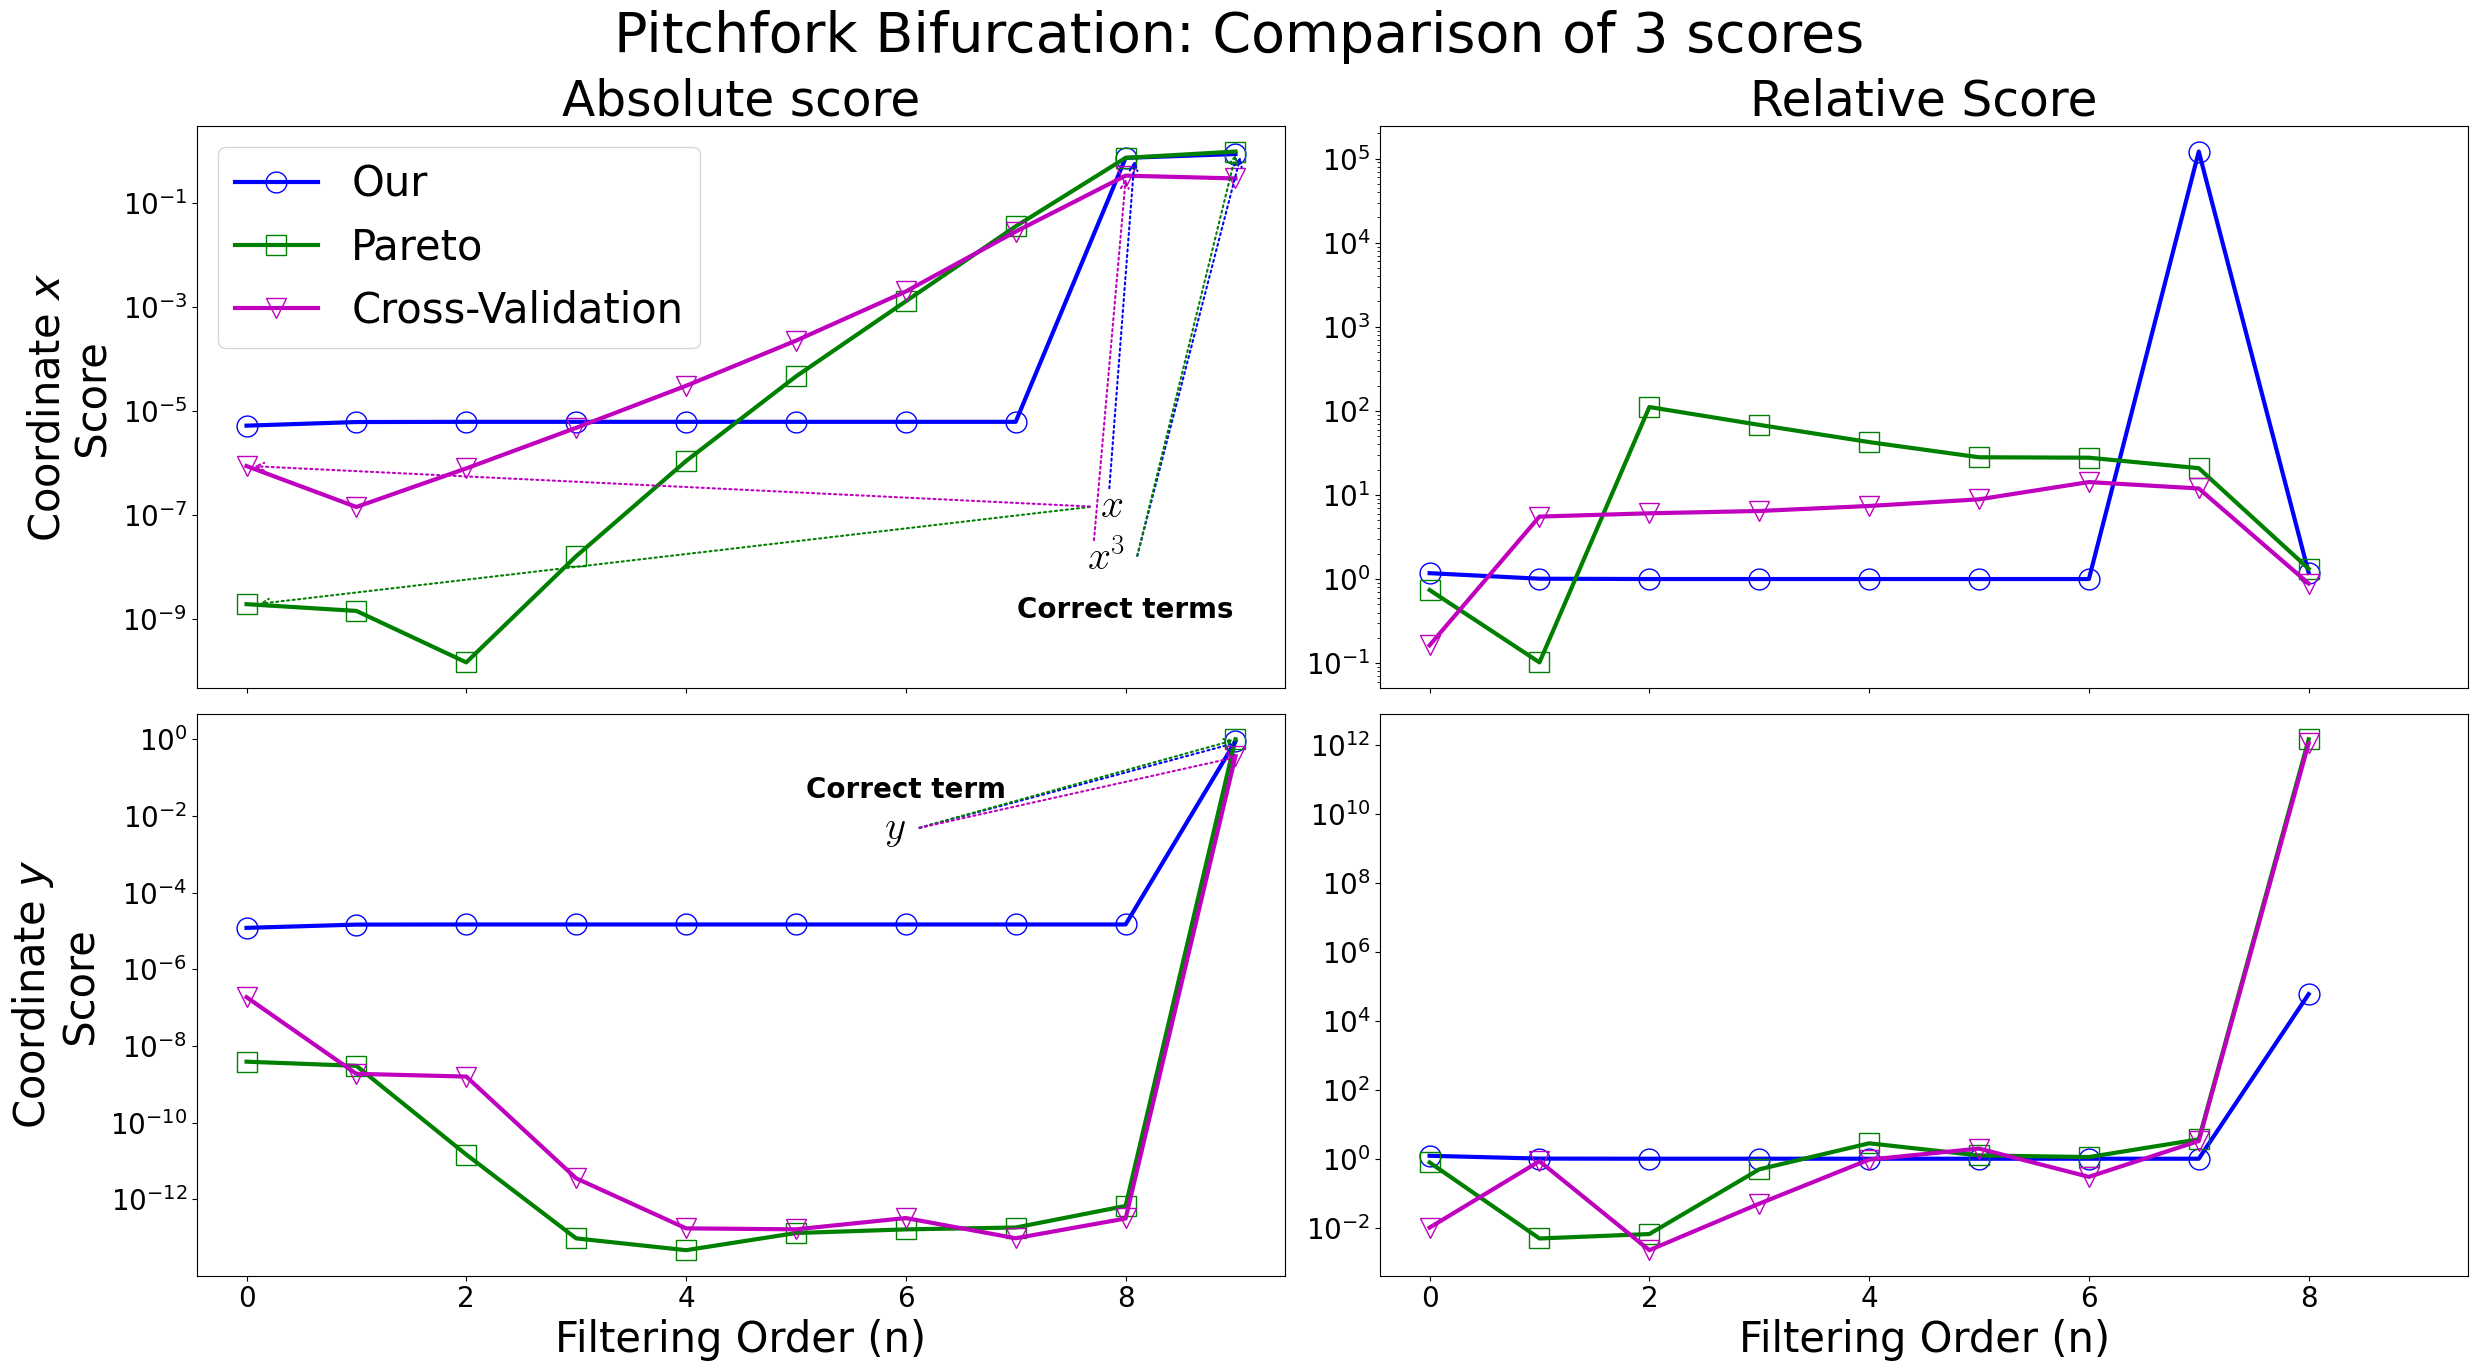

In [ ]:
#create figure
line_style = ['dashed', 'dotted']
scores_labels = ['Our', 'Pareto', 'Cross-Validation']
markers = ['o', 's', 'v']
colors = ['b', 'g', 'm']
sizes = [4,8]
fs = 30
fig, ax = plt.subplots(2,2,figsize=(25, 14), sharex=True)

fig.suptitle('Pitchfork Bifurcation: Comparison of 3 scores', fontsize=40)
ax[0,0].set_title('Absolute score', fontsize=35)
ax[0,1].set_title('Relative Score', fontsize=35)
n_terms = [2,1]  # Manually set based on previous jumps detected
n_terms = [No_D - n for n in n_terms]



filt_order = []
filt_order.append(filtering_order)
filt_order.append(filtering_order_pareto)
filt_order.append(filtering_order_cv)

hist_score = []
hist_score.append(history_value_removed)
hist_score.append(history_value_pareto)
hist_score.append(history_value_cv)

rel_scores = []
rel_scores.append(history_value_removed[:,1:] / history_value_removed[:,:-1])
rel_scores.append(history_value_pareto[:,1:] / history_value_pareto[:,:-1])
rel_scores.append(history_value_cv[:,1:] / history_value_cv[:,:-1])


for idx in range(history_value_removed.shape[0]):
    for i in range(len(filt_order)):
        ax[idx,0].plot(hist_score[i][idx], color=colors[i], marker=markers[i], label=f'{scores_labels[i]}', lw = 3, markersize=15,markerfacecolor='none')
        ax[idx,1].plot(rel_scores[i][idx], color=colors[i], marker=markers[i], label=f'{scores_labels[i]}', lw = 3, markersize=15,markerfacecolor='none')


for idx in range(history_value_removed.shape[0]):
    if idx == 0:
        height = np.min([hist_score[i][idx] for i in range(len(filt_order))]).min() * 1e3
        loc = 8
        ax[idx,0].text(
                loc, height/100, 
                f"Correct terms", 
                ha='center', va='center', fontsize=20, color='k', fontweight='bold'
            )
    else:
        height = np.min([hist_score[i][idx] for i in range(len(filt_order))]).min() * 1e11
        loc = 6
        ax[idx,0].text(
                loc, height*10, 
                f"Correct term", 
                ha='center', va='center', fontsize=20, color='k', fontweight='bold'
            )

    for j, term in enumerate(correct_terms[idx]):
        with mpl.rc_context({'text.usetex': True, 'font.family': 'serif'}):
            ax[idx,0].text(
                loc, height, 
                f"${name_tag[term]}$", 
                ha='right', va='center', fontsize=fs, color='k', fontweight='bold'
            )
        for i in range(len(filt_order)):
            score_loc = np.argwhere(filt_order[i][idx] == term)[0] 
            loc_pos = score_loc+ np.random.rand(1)*0.1
            if score_loc > loc:
                ax[idx,0].annotate(
                    '', 
                    xy=(loc_pos, hist_score[i][idx][score_loc]), 
                    xytext=(loc+0.1, height),  # Arrow starts from top left
                    arrowprops=dict(arrowstyle="->", color=colors[i], lw=1.5,linestyle='dotted') ,
                    annotation_clip=False
                )
            elif score_loc < loc:
                ax[idx,0].annotate(
                    '', 
                    xy=(loc_pos, hist_score[i][idx][score_loc]), 
                    xytext=(loc-0.3, height),  # Arrow starts from top left
                    arrowprops=dict(arrowstyle="->", color=colors[i], lw=1.5,linestyle='dotted') ,
                    annotation_clip=False
                )
            else:
                ax[idx,0].annotate(
                    '', 
                    xy=(loc_pos, hist_score[i][idx][score_loc]), 
                    xytext=(loc-(0.15 + i*0.07), height*2),  # Arrow starts from top left
                    arrowprops=dict(arrowstyle="->", color=colors[i], lw=1.5,linestyle='dotted') ,
                    annotation_clip=False
                )
        height /=10


for i, ai in enumerate(ax):
    ai[0].set_ylabel(f'Coordinate {coords[i]}\n Score', fontsize=fs)
    for j, a in enumerate(ai):
        a.set_yscale('log')
        a.tick_params(axis='both', which='major', labelsize=20)


ax[0,0].legend(fontsize=fs)
ax[-1,0].set_xlabel('Filtering Order (n)', fontsize=fs)
ax[-1,1].set_xlabel('Filtering Order (n)', fontsize=fs)

plt.tight_layout()
plt.savefig('Figs/compare_three_scores_pitchfork.pdf', format='pdf')
